In [25]:
################################################################################
# Load dataset and split it into training and test set
################################################################################

import pandas as pd
import os
from tabulate import tabulate

dataset_name = "cic-iot"
sample_size = 100000

# Load dateset
df = pd.read_csv(os.getcwd() + f'/data/sample-{sample_size}-2.csv')

# Split dataset according to attack type
normal_df = df[df['label'] == 'BenignTraffic']
attack_df = df[df['label'] != 'BenignTraffic']

# Drop columns
normal_df = normal_df.drop(columns=['label'])
attack_df = attack_df.drop(columns=['label'])

# Split dataset into training and test set
normal_df_train = normal_df.sample(frac=0.8, random_state=42)
normal_df_test = normal_df.drop(normal_df_train.index)
attack_df_train = attack_df.sample(frac=0.8, random_state=42)
attack_df_test = attack_df.drop(attack_df_train.index)

# Print dataset sizes in a table
data = [
    ["Normal", normal_df.shape[0], normal_df_train.shape[0], normal_df_test.shape[0]],
    ["Attack", attack_df.shape[0], attack_df_train.shape[0], attack_df_test.shape[0]]
]
print(tabulate(data, headers=["Attack type", "Total", "Train", "Test"], tablefmt="grid"))

+---------------+---------+---------+--------+
| Attack type   |   Total |   Train |   Test |
+===============+=========+=========+========+
| Normal        |    2348 |    1878 |    470 |
+---------------+---------+---------+--------+
| Attack        |   97652 |   78122 |  19530 |
+---------------+---------+---------+--------+


In [26]:
################################################################################
# Vector Store
################################################################################

import json
import numpy as np
from langchain_chroma import Chroma
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

train_set_size = sample_size
n_results = 10
embeddings = HuggingFaceEmbeddings()
vector_store = Chroma(
    collection_name=dataset_name,
    embedding_function=embeddings,
    persist_directory=f"./vector-stores/chroma-db-{train_set_size}-2")

normal_vectors = vector_store._collection.get(include=['embeddings'], where={'label': 'normal'})['embeddings']
normal_mean_vector = np.mean(normal_vectors, axis=0).tolist()
normal_documents = \
    vector_store._collection.query(query_embeddings=[normal_mean_vector], n_results=n_results)['documents'][0]

attack_vectors = vector_store._collection.get(include=['embeddings'], where={'label': 'attack'})['embeddings']
attack_mean_vector = np.mean(attack_vectors, axis=0).tolist()
attack_documents = \
    vector_store._collection.query(query_embeddings=[attack_mean_vector], n_results=n_results)['documents'][0]

def parse_document(doc):
    try:
        return json.loads(doc)
    except (json.JSONDecodeError, ValueError):
        import ast
        return ast.literal_eval(doc)

feature_names = normal_df_train.columns.to_list()
doc_length = len(parse_document(normal_documents[0]))
valid_features = feature_names[:doc_length]

normal_entries_dict = {}
for i, feature_name in enumerate(valid_features):
    normal_entries_dict[feature_name] = [parse_document(doc)[i] for doc in normal_documents]

attack_doc_length = len(parse_document(attack_documents[0]))
valid_attack_features = feature_names[:attack_doc_length]

attack_entries_dict = {}
for i, feature_name in enumerate(valid_attack_features):
    attack_entries_dict[feature_name] = [parse_document(doc)[i] for doc in attack_documents]

In [27]:
################################################################################
# State
################################################################################

from langgraph.graph import MessagesState


class State(MessagesState):
    i: int

In [28]:
################################################################################
# Policy Evaluate Tool
################################################################################

import operator
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from typing import Annotated
from langchain_core.tools import tool

show_progress = False
operators = {'<': operator.lt, '>': operator.gt, '==': operator.eq, '<=': operator.le, '>=': operator.ge,
              '!=': operator.ne}


def _feature_key(name):
    """Normalize feature names so model-generated aliases like Tot_size match Tot size."""
    return ''.join(ch.lower() for ch in str(name).strip().strip("`'\"") if ch.isalnum())


def resolve_feature_name(feature_name, columns=None):
    columns = list(columns if columns is not None else normal_df_train.columns)
    if feature_name in columns:
        return feature_name

    feature_key = _feature_key(feature_name)
    matches = [column for column in columns if _feature_key(column) == feature_key]
    if len(matches) == 1:
        return matches[0]

    raise ValueError(f"Unknown feature '{feature_name}'. Available features: {columns}")


@tool
def policy_evaluate_tool(
        feature_name: Annotated[str, "Feature name"],
        value: Annotated[float, "Value"],
        op: Annotated[str, "Operator"]
) -> float:
    """Evaluate the policy and return the macro f1-score."""
    print("PET>", end="")
    try:
        value = float(value)
    except ValueError:
        value
    datasets = {"normal": normal_df_train, "attack": attack_df_train}
    try:
        feature_name = resolve_feature_name(feature_name, normal_df_train.columns)
    except ValueError as e:
        print(f"\n{e}")
        return 0.0
    y_pred = []
    y_true = []
    if op in operators:
        for attack_type, dataset in datasets.items():
            test_set_size = dataset.shape[0]
            for i in tqdm(range(test_set_size), ncols=100, desc=f"Predicting {attack_type} entries...",
                          disable=not show_progress):
                y_true.append(attack_type)
                y_pred.append("attack" if operators[op](dataset.iloc[i][feature_name], value) else "normal")
        c_report = classification_report(y_true, y_pred, digits=4, output_dict=True)
        return c_report['macro avg']['f1-score']
    else:
        raise ValueError(f"Unsupported operator: {op}")

In [29]:
################################################################################
# Long-term Memory Write Tool
################################################################################

import sqlite3
from typing import List


@tool
def lt_memory_write_tool(policy: List[str]) -> bool:
    """
    Write a policy to the SQL database.

    Args:
        policy (List[str]): ['feature', 'operator', 'value', 'f1_score', 'comment']

    Returns:
        bool: True if the policy is successfully written to the database, False otherwise.
    """
    print("MWT>", end="")
    try:
        # Create a connection to a SQLite database
        db_name = "results/database.db"
        connection = sqlite3.connect(db_name)

        # Write data to the database
        table_name = "lt_memory"
        cursor = connection.cursor()

        # Create the table if it does not exist
        cursor.execute(
            f"CREATE TABLE IF NOT EXISTS {table_name} (feature TEXT  PRIMARY KEY, operator TEXT, value TEXT, f1_score TEXT, comment TEXT)")

        # Insert the policy into the table
        cursor.execute(f"INSERT OR REPLACE INTO {table_name} VALUES (?, ?, ?, ?, ?)",
                       [str(element) for element in policy])

        # Commit the changes
        connection.commit()

        # Close the connection
        connection.close()

        return True
    except Exception as e:
        print(e)
        return False


In [30]:
################################################################################
# Function for retrieving previous policies from Long-term Memory
################################################################################

import sqlite3


def get_previous_policies(as_string=False, filtered=False):
    try:
        # Create a connection to a SQLite database
        db_name = "results/database.db"
        connection = sqlite3.connect(db_name)
        connection.row_factory = sqlite3.Row

        # Read data from the database
        table_name = "lt_memory"
        cursor = connection.cursor()

        # Create the table if it does not exist
        cursor.execute(
            f"CREATE TABLE IF NOT EXISTS {table_name} (feature TEXT PRIMARY KEY, operator TEXT, value TEXT, f1_score TEXT, comment TEXT)")

        # Read the policies from the table
        cursor.execute(f"SELECT * FROM {table_name}")
        rows = cursor.fetchall()

        # Close the connection
        connection.close()

        fetched_policies = [dict(row) for row in rows]

        def safe_float(value):
            try:
                return float(value)
            except (ValueError, TypeError):
                return 0

        try:
            sorted_policies = sorted(fetched_policies, key=lambda x: safe_float(x['f1_score']), reverse=True)
        except Exception as e:
            print(e)
            sorted_policies = fetched_policies

        if as_string:
            str_policies = []
            for sorted_policy in sorted_policies:
                policy = f"Policy: {sorted_policy['feature']} {sorted_policy['operator']} {sorted_policy['value']}, F1-Score: {sorted_policy['f1_score']}, Comment: {sorted_policy['comment']}"
                str_policies.append(policy)
            return "\n".join(str_policies[:k])

        return sorted_policies
    except Exception as e:
        print(e)
        return []

In [31]:
################################################################################
# Function for getting filtered messages
################################################################################

from langchain_core.messages import SystemMessage, HumanMessage
import uuid
import json

normal_entries = json.dumps(normal_entries_dict)
attack_entries = json.dumps(attack_entries_dict)


def get_init_messages(init=False):
    if init:
        system_message = SystemMessage(f"""
        You are a skilled security data analyst. Your task is to generate effective filtering policies to identify attack entries in network data. Follow these steps carefully:

        Input data analysis:
        1. You will receive network data entries labeled as either 'normal' or 'attack,' along with their feature names.
        2. Analyze the key differences between 'normal' and 'attack' entries by comparing feature values.

        Policy generation:
        1. Your goal is to create exactly {k} simple and deterministic policies based on the top {k} important features that can filter out 'attack' entries.
        2. Use only the following operators: >, <, >=, <= for continuous numeric features. You MAY use '==' or '!=' ONLY for categorical or discrete features (e.g., string values, port numbers, protocol types, binary flags).
        3. Use feature names exactly as listed in the input. Do not replace spaces with underscores or rename features.
        4. Policies should be designed so that when a policy evaluates to TRUE, the entry is classified as 'attack'; otherwise, it is classified as 'normal.'

        Evaluation:
        1. Generate a tool call for each policy to test its effectiveness.
        2. Evaluate the performance of each policy and compute the F1-score.

        Output Requirements:
        Finally, only output the complete set of {k} policies along with their corresponding F1-scores.
        """, id=str(uuid.uuid4()))
        human_message = HumanMessage(f"""
        Below is the network data categorized into 'normal' and 'attack' entries, along with their corresponding feature names. Your task is as follows:

        Policy Generation: Generate {k} policies based on the top {k} important features to filter out 'attack' entries effectively.

        Policy Evaluation: Evaluate each policy using the 'policy_evaluate_tool' by making a tool call for every generated policy.

        Output Requirements: Provide the generated policies along with their corresponding F1-scores.

        Available Feature Names:
        ```{json.dumps(feature_names)}```

        Normal Entries:
        ```{json.dumps(normal_entries_dict)}```

        Attack Entries:
        ```{json.dumps(attack_entries_dict)}```
        """, id=str(uuid.uuid4()))
    else:
        system_message = SystemMessage(f"""
        You are a skilled security data analyst. Your task is to generate effective filtering policies to identify attack entries in network data. Follow these steps carefully:

        Input data analysis:
        1. You will receive network data entries labeled as either 'normal' or 'attack,' along with their feature names.
        2. Analyze the key differences between 'normal' and 'attack' entries by comparing feature values.
        3. Additionally, you will be given some knowledge from previously generated policies.

        Policy generation:
        1. Use the previous knowledge as a reference to generate NEW policies, but do not generate the same policies.
        2. Your goal is to create exactly {k} NEW simple and deterministic policies based on the top {k} important features that can filter out 'attack' entries.
        3. Use only the following operators: >, <, >=, <= for continuous numeric features. You MAY use '==' or '!=' ONLY for categorical or discrete features (e.g., string values, port numbers, protocol types, binary flags).
        4. Use feature names exactly as listed in the input. Do not replace spaces with underscores or rename features.
        5. Policies should be designed so that when a policy evaluates to TRUE, the entry is classified as 'attack'; otherwise, it is classified as 'normal'.

        Evaluation:
        1. Generate a tool call for each NEW policy to test its effectiveness.
        2. Make all the tool calls at once.

        Output Requirements:
        Finally, only output the complete set of {k} policies along with their corresponding F1-scores.
        """, id=str(uuid.uuid4()))
        human_message = HumanMessage(f"""
        Below is the network data categorized into 'normal' and 'attack' entries, along with their corresponding feature names. After that you are given previously generated policies.

        Available Feature Names:
        ```
        {json.dumps(feature_names)}
        ```

        Normal Entries:
        ```
        {json.dumps(normal_entries_dict)}
        ```

        Attack Entries:
        ```
        {json.dumps(attack_entries_dict)}
        ```

        Knowledge:
        ```
        {get_previous_policies(as_string=True)}
        ```

        Your task is as follows:

        Policy Generation: Generate {k} NEW policies based on the top {k} important features to filter out 'attack' entries effectively. You can improve a previously generated policy based on the comment, or create NEW policies using different features.

        Policy Evaluation: Evaluate each policy using the 'policy_evaluate_tool' by making a tool call for every generated policy.

        Output Requirements: Provide the generated policies along with their corresponding F1-scores.
        """, id=str(uuid.uuid4()))
    return [system_message, human_message]

In [51]:
################################################################################
# Policy Generator Node
################################################################################

from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_anthropic import ChatAnthropic
import dotenv
import os

dotenv.load_dotenv(os.getcwd() + '/../.env')

# OpenAI
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.1)
# llm = ChatOpenAI(model="gpt-4o", temperature=0.1)

# Google Generative AI
# llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash", temperature=0.1)
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0.1)

# Anthropic
# llm = ChatAnthropic(model="claude-3-5-haiku-latest", temperature=0.1)
# llm = ChatAnthropic(model="claude-3-5-sonnet-latest", temperature=0.1)

# Ollama
# llm = ChatOllama(model="llama3.1:8b", base_url="http://192.168.4.29:11434")

llm_with_policy_evaluate_tool = llm.bind_tools([policy_evaluate_tool])


def policy_generator(state):
    print("PG>", end="")
    if len(state["messages"]) > 0 and isinstance(state["messages"][-1], ToolMessage):
        last_messages = []
        for msg in reversed(state["messages"]):
            last_messages.append(msg)
            if isinstance(msg, SystemMessage):
                break
        ai_message = llm_with_policy_evaluate_tool.invoke(list(reversed(last_messages)))
        return {"messages": [ai_message]}
    else:
        init_messages = get_init_messages(init=state["i"] == 0)
        ai_message = llm_with_policy_evaluate_tool.invoke(init_messages)
        return {"messages": init_messages + [ai_message]}

In [33]:
################################################################################
# Persistence Filter Node
################################################################################

llm_with_lt_memory_write_tool = llm.bind_tools([lt_memory_write_tool])


def persistence_filter(state):
    print("PF>", end="")
    if len(state["messages"]) > 0 and isinstance(state["messages"][-1], ToolMessage):
        last_messages = []
        for msg in reversed(state["messages"]):
            last_messages.append(msg)
            if isinstance(msg, SystemMessage):
                break
        ai_message = llm_with_policy_evaluate_tool.invoke(list(reversed(last_messages)))
        return {"messages": [ai_message]}
    else:
        system_message = SystemMessage(f"""
        You are good at comparing values.
        Compare old and new policies with similar feature name based on their performance.
        Your task is to compare and contrast the newly generated policies with the previously generated ones and pick policies with higher f1-score.
        Also, provide insightful comments about their relative strengths and weaknesses.

        Comparison:
        1. For a given feature name, if there is a old policy, compare the f1-score of new policy with the old policy.
        2. If the new policy outperforms the old one, explain why in the comment (e.g., better value ranges, or enhanced conditions).
        3. If the old policy is better, specify what made it more effective in the comment.
        4. Make sure only the policy with the highest F1-score is retained.
        5. If there is no old policy for comparison, use the default comment: "This is the first policy for this feature.".

        Tool Calls to save new policies with the comment:
        1. For each feature, make a tool call to 'lt_memory_write_tool' to insert or replace ONLY top performing policy from old and new.
        2. The tool expects a list of strings: ['feature', 'operator', 'value', 'f1_score', 'comment'].
        3. Make all the tool calls at once after comparing all the policies.

        Example comment:
        "When the value of 'x_count' increased from 0.5 to 0.6, the F1-score improved from 0.8 to 0.9. However, increasing it further to 0.7 caused the F1-score to drop to 0.7. This indicates the optimal range is between 0.5 and 0.6."

        Output Requirements: Finally output the a summary of the new policies in one sentence.
        """, id=str(uuid.uuid4()))
        compound_msg = f"""
        Old Policies:
        ```
        {get_previous_policies(as_string=True)}
        ```

        New Policies:
        ```
        {state["messages"][-1].content}
        ```
        """
        init_messages = [system_message, HumanMessage(compound_msg, id=str(uuid.uuid4()))]
        ai_message = llm_with_lt_memory_write_tool.invoke(init_messages)
        return {"messages": init_messages + [ai_message]}


In [34]:
################################################################################
# Feedback Controller Node
################################################################################

from sklearn.metrics import classification_report, confusion_matrix
from statistics import mode
from tqdm import tqdm


def feedback_controller(state):
    print("FC>")
    sorted_policies = get_previous_policies()
    datasets = {"normal": normal_df_test, "attack": attack_df_test}
    resolved_policies = []
    for policy in sorted_policies[:k]:
        try:
            resolved_policy = dict(policy)
            resolved_policy['feature'] = resolve_feature_name(policy['feature'], normal_df_test.columns)
            resolved_policies.append(resolved_policy)
        except ValueError as e:
            print(f"Skipping policy: {e}")
    if not resolved_policies:
        print("No valid policies available for feedback evaluation.")
        return {"i": state["i"] + 1}
    y_pred = []
    y_true = []
    for attack_type, dataset in datasets.items():
        test_set_size = dataset.shape[0]
        for i in tqdm(range(test_set_size), ncols=100, desc=f"Predicting {attack_type} entries...",
                      disable=not show_progress):
            try:
                predicted_attack_types = []
                for policy in resolved_policies:
                    feature_name = policy['feature']
                    op = policy['operator']
                    value = policy['value']
                    try:
                        value = float(value)
                    except ValueError:
                        value
                    predicted_attack_types.append(
                        "attack" if operators[op](dataset.iloc[i][feature_name], value) else "normal")
                y_true.append(attack_type)
                y_pred.append(mode(predicted_attack_types))
            except Exception as e:
                continue
    c_report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    c_matrix = confusion_matrix(y_true, y_pred)
    print(c_report['macro avg']['f1-score'])
    print(c_matrix)
    c_reports.append(c_report)
    c_matrices.append(c_matrix)
    return {"i": state["i"] + 1}

In [35]:
################################################################################
# Conditional Edge for Policy Evaluation Tool
################################################################################

def p_eval_conditional_edge(state):
    if isinstance(state, list):
        ai_message = state[-1]
    elif isinstance(state, dict) and (messages := state.get("messages", [])):
        ai_message = messages[-1]  # Default case
    elif messages := getattr(state, "messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "policy_evaluate_tool"
    return "persistence_filter"

In [36]:
################################################################################
# Conditional Edge for Policy Evaluation Tool
################################################################################

def lt_mem_conditional_edge(state):
    if isinstance(state, list):
        ai_message = state[-1]
    elif isinstance(state, dict) and (messages := state.get("messages", [])):
        ai_message = messages[-1]  # Default case
    elif messages := getattr(state, "messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "lt_memory_write_tool"
    return "feedback_controller"

In [37]:
################################################################################
# Conditional Edge for Feedback
################################################################################

def feedback_conditional_edge(state):
    if state["i"] < n:
        return "policy_generator"
    return "__end__"

In [38]:
################################################################################
# Long-term Memory Cleanup
################################################################################

# Delete all the policies from the database
connection = sqlite3.connect("results/database.db")
cursor = connection.cursor()
cursor.execute("CREATE TABLE IF NOT EXISTS lt_memory (feature TEXT PRIMARY KEY, operator TEXT, value TEXT, f1_score TEXT, comment TEXT)")
cursor.execute("DELETE FROM lt_memory")
connection.commit()

cursor.execute(f"SELECT * FROM lt_memory")
assert len(cursor.fetchall()) == 0

connection.close()


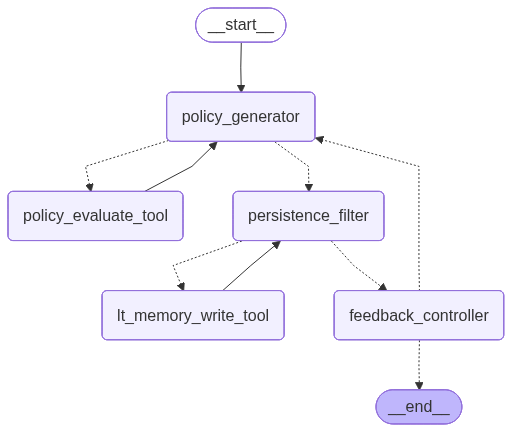

In [39]:
################################################################################
# Graph
################################################################################

from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
def make_tool_node(tools):
    """Custom ToolNode: langgraph.prebuilt.ToolNode unavailable in langgraph 0.2.x."""
    tools_by_name = {t.name: t for t in tools}
    def tool_node(state):
        last_ai_msg = next(
            m for m in reversed(state["messages"])
            if hasattr(m, "tool_calls") and m.tool_calls
        )
        results = []
        for tc in last_ai_msg.tool_calls:
            result = tools_by_name[tc["name"]].invoke(tc["args"])
            results.append(ToolMessage(content=str(result), tool_call_id=tc["id"]))
        return {"messages": results}
    return tool_node

builder = StateGraph(State)

builder.add_node("policy_generator", policy_generator)
builder.add_node("policy_evaluate_tool", make_tool_node([policy_evaluate_tool]))
builder.add_node("persistence_filter", persistence_filter)
builder.add_node("lt_memory_write_tool", make_tool_node([lt_memory_write_tool]))
builder.add_node("feedback_controller", feedback_controller)

builder.add_edge(START, "policy_generator")
builder.add_conditional_edges("policy_generator", p_eval_conditional_edge,
                              ["policy_evaluate_tool", "persistence_filter"])
builder.add_edge("policy_evaluate_tool", "policy_generator")
builder.add_conditional_edges("persistence_filter", lt_mem_conditional_edge,
                              ["lt_memory_write_tool", "feedback_controller"])
builder.add_edge("lt_memory_write_tool", "persistence_filter")
builder.add_conditional_edges("feedback_controller", feedback_conditional_edge, ["policy_generator", END])

memory_saver = MemorySaver()
graph = builder.compile(checkpointer=memory_saver, interrupt_before=[])
display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
################################################################################
# Invoke Graph
################################################################################

# Configurations
k = 5  # Number of policies
n = 5  # Number of iterations
c_reports = []
c_matrices = []

state = State(i=0, messages=[])
config = {"configurable": {"thread_id": 1}, "recursion_limit": 100}
output = graph.invoke(state, config)

PG>

KeyboardInterrupt: 

In [41]:
################################################################################
# Long-term Memory Visualizer
################################################################################

import datetime

policies = get_previous_policies()
print(tabulate(policies, headers="keys", tablefmt="grid"))

# Save this tabulate table to a file with name as the current timestamp
if len(policies) > 0:
    try:
        llm_name = llm.model_name
    except AttributeError:
        llm_name = llm.model
    llm_name = llm_name.replace("/", "-")
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
    file_name = f"results/policies-{timestamp}-{llm_name}.txt"
    with open(file_name, "w") as file:
        file.write(f">>> Results for {llm_name} of sample size {sample_size}\n\n")
        file.write(tabulate(policies, headers="keys", tablefmt="grid"))
        file.write("\n\n")
        for i in range(len(c_reports)):
            file.write(f"{c_reports[i]}\n")
            file.write(f"{c_matrices[i]}\n\n")



## Complex Policy Generation — Expressive Boolean Expressions

Extends the pipeline so policies can be full Python boolean expressions rather than single `feature op value` rules. The LLM is shown all expression types and **chooses freely** based on what the data supports — no preference is imposed.

| Expression type | Example |
|---|---|
| Simple threshold | `urg_count < 3` |
| Range | `0 <= urg_count < 3` |
| OR (disjunction) | `urg_count < 3 or flow_duration < 5` |
| Derived ratio | `IAT / (ack_count + 1) < 0.01` |
| Combined | `(urg_count < 3) and (flow_duration < 5 or Header_Length < 40000)` |

**Fixes applied from the Bot-IoT failure analysis:**
- Feature name safety: space-containing names (`Tot sum`, `Protocol Type`) are aliased with underscores at eval time
- No F1 discard threshold: persistence filter always keeps the top-k expressions
- Class distribution provided as neutral context only — no steering toward any expression type


In [ ]:
################################################################################
# Complex Policy Evaluate Tool + Long-term Memory  (HIGH-PRIORITY UPDATES)
# Changes vs original:
#   1. _pred_cache stores the training-set prediction vector for every evaluated
#      expression so Jaccard-based diversity can be computed cheaply.
#   2. complex_lt_memory_write_tool rejects expressions that agree with an already-
#      stored policy on >95 % of training rows (disagreement < 0.05).
#   3. _hard_cases dict is initialised here; filled by complex_feedback_controller.
################################################################################

import math, sqlite3, numpy as np
from typing import Annotated, List
from langchain_core.tools import tool
from tqdm import tqdm
from sklearn.metrics import classification_report

safe_builtins = {
    "abs": abs, "max": max, "min": min, "round": round,
    "log": math.log, "log2": math.log2, "sqrt": math.sqrt, "exp": math.exp,
}
_cx_globals = {"__builtins__": {}, **safe_builtins}

_cx_feature_aliases = {
    col.replace(" ", "_"): col
    for col in normal_df_train.columns
    if " " in col
}

def _make_eval_row(row: dict) -> dict:
    result = dict(row)
    for safe_name, orig_name in _cx_feature_aliases.items():
        if orig_name in result:
            result[safe_name] = result[orig_name]
    return result

# Prediction cache: expression → numpy bool array (True = predicted attack)
# Populated by complex_policy_evaluate_tool; used by write tool for diversity check.
_pred_cache: dict = {}

# Hard cases from the previous feedback round; filled by complex_feedback_controller.
_hard_cases: dict = {"attack_fn": [], "normal_fp": []}


@tool
def complex_policy_evaluate_tool(
    expression: Annotated[str, (
        "A Python boolean expression using eval-safe feature names (spaces → underscores). "
        "Supports ranges, OR conditions, derived features, and combinations. "
        "TRUE → attack, FALSE → normal."
    )]
) -> float:
    """Evaluate a complex boolean expression and return macro F1-score."""
    print("CPET>", end="")
    datasets = {"normal": normal_df_train, "attack": attack_df_train}
    y_pred, y_true, train_preds = [], [], []
    for attack_type, dataset in datasets.items():
        for i in tqdm(range(dataset.shape[0]), ncols=100,
                      desc=f"Predicting {attack_type}...", disable=not show_progress):
            row = _make_eval_row(dataset.iloc[i].to_dict())
            try:
                result = bool(eval(expression, _cx_globals, row))
            except Exception:
                result = False
            y_pred.append("attack" if result else "normal")
            y_true.append(attack_type)
            train_preds.append(result)
    # Cache prediction vector for diversity checking
    _pred_cache[expression] = np.array(train_preds, dtype=bool)
    c_report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    return c_report["macro avg"]["f1-score"]


@tool
def complex_lt_memory_write_tool(policy: List[str]) -> bool:
    """
    Write a complex policy expression to the SQL database.
    Rejects the expression if it is too similar (disagreement < 0.05) to any
    already-stored policy, preventing clone accumulation in the bank.
    Args:
        policy (List[str]): ['expression', 'f1_score', 'comment']
    """
    print("CMWT>", end="")
    expression = policy[0]

    # ── Diversity check ──────────────────────────────────────────────────────
    new_pred = _pred_cache.get(expression)
    if new_pred is not None:
        for stored_p in get_previous_complex_policies():
            stored_pred = _pred_cache.get(stored_p["expression"])
            if stored_pred is not None and len(stored_pred) == len(new_pred):
                disagreement = float(np.mean(new_pred != stored_pred))
                if disagreement < 0.05:
                    print(f"DIV_REJECT(d={disagreement:.3f})>", end="")
                    return False   # too similar — do not save
    # ─────────────────────────────────────────────────────────────────────────

    try:
        conn = sqlite3.connect("results/database.db")
        cur = conn.cursor()
        cur.execute(
            "CREATE TABLE IF NOT EXISTS complex_lt_memory "
            "(expression TEXT PRIMARY KEY, f1_score TEXT, comment TEXT)"
        )
        cur.execute("INSERT OR REPLACE INTO complex_lt_memory VALUES (?, ?, ?)",
                    [str(e) for e in policy])
        conn.commit()
        conn.close()
        return True
    except Exception as e:
        print(e)
        return False


def get_previous_complex_policies(as_string=False):
    try:
        conn = sqlite3.connect("results/database.db")
        conn.row_factory = sqlite3.Row
        cur = conn.cursor()
        cur.execute(
            "CREATE TABLE IF NOT EXISTS complex_lt_memory "
            "(expression TEXT PRIMARY KEY, f1_score TEXT, comment TEXT)"
        )
        cur.execute("SELECT * FROM complex_lt_memory")
        rows = [dict(r) for r in cur.fetchall()]
        conn.close()

        def _f(v):
            try: return float(v)
            except: return 0.0

        rows = sorted(rows, key=lambda x: _f(x["f1_score"]), reverse=True)
        if as_string:
            return "\n".join(
                f"Expression: {p['expression']}, F1: {p['f1_score']}, Comment: {p['comment']}"
                for p in rows[:k]
            )
        return rows
    except Exception as e:
        print(e)
        return []


In [ ]:
################################################################################
# Complex Policy Prompt  (HIGH-PRIORITY UPDATES)
# Changes vs original:
#   1. _extract_dominant_features() identifies features that appear in >50 % of
#      stored expressions.
#   2. Non-init prompt includes a FEATURE DIVERSITY CONSTRAINT telling the LLM
#      to use a different primary feature for at least k//2 of its expressions.
#   3. Non-init prompt injects hard cases (misclassified rows from the previous
#      feedback round) so the LLM targets the system's current blind spots.
################################################################################

import json, uuid
from langchain_core.messages import SystemMessage, HumanMessage

_eval_safe_feature_names = []
for col in feature_names:
    safe = col.replace(" ", "_")
    _eval_safe_feature_names.append(safe if safe != col else col)

_EXPRESSION_EXAMPLES = (
    "SUPPORTED EXPRESSION TYPES (choose whichever fits the data best):\n"
    "  Simple threshold:  urg_count < 3\n"
    "  Range:             0 <= urg_count < 3\n"
    "  OR (disjunction):  urg_count < 3 or flow_duration < 5\n"
    "  Derived ratio:     IAT / (ack_count + 1) < 0.01\n"
    "  Combined:          (urg_count < 3) and (flow_duration < 5 or Header_Length < 40000)\n"
    "  Multi-flag:        syn_flag_number > 0 or rst_flag_number > 0\n"
)

_CLASS_CONTEXT = (
    "Dataset context: ~97.65 % of rows are attacks, ~2.35 % are normal.\n"
    "Choose expression types based on what the data shows — all types above are valid.\n"
)


def _extract_dominant_features(expressions: list) -> list:
    """Return features that appear in more than half of the given expressions."""
    from collections import Counter
    counts = Counter()
    for expr in expressions:
        for feat in _eval_safe_feature_names:
            if feat in expr:
                counts[feat] += 1
    threshold = max(1, len(expressions) // 2)
    return [f for f, c in counts.items() if c >= threshold]


def _format_hard_cases(rows: list) -> dict:
    """Convert a list of row dicts to feature-indexed format matching entries_dict."""
    if not rows:
        return {}
    # Use eval-safe names only
    safe_rows = []
    for row in rows:
        safe_row = {}
        for k_col, v in row.items():
            safe_k = k_col.replace(" ", "_")
            if safe_k in _eval_safe_feature_names:
                safe_row[safe_k] = v
        safe_rows.append(safe_row)
    # Transpose to feature-indexed dict
    all_keys = list(safe_rows[0].keys()) if safe_rows else []
    return {feat: [r.get(feat) for r in safe_rows] for feat in all_keys}


def get_complex_init_messages(init=False):
    eval_feature_list = json.dumps(_eval_safe_feature_names)

    if init:
        system_message = SystemMessage(f"""
You are a skilled security data analyst generating Python boolean expressions
as filtering policies to identify attack entries in IoT network traffic.

{_CLASS_CONTEXT}
{_EXPRESSION_EXAMPLES}

Rules:
- Each expression is evaluated per row: TRUE → 'attack', FALSE → 'normal'.
- Generate exactly {k} expressions using the most discriminative features.
- Use ONLY features from the list below. For features with spaces in the original
  name, use the underscore version (e.g., 'Tot_sum' not 'Tot sum').
- All Python operators are valid: +, -, *, /, <, >, ==, !=, and, or, not, parentheses.
- Choose the expression type that best fits each feature's data distribution.
- Evaluate each expression with 'complex_policy_evaluate_tool' (one call per expression).

Available eval-safe feature names:
{eval_feature_list}

Output: {k} expressions with their F1-scores.
        """, id=str(uuid.uuid4()))
        human_message = HumanMessage(f"""
Analyse the differences between 'normal' and 'attack' entries below,
then generate {k} boolean expressions that best distinguish attack from normal traffic.

Normal Entries:
```{json.dumps(normal_entries_dict)}```

Attack Entries:
```{json.dumps(attack_entries_dict)}```

Evaluate each with 'complex_policy_evaluate_tool'.
        """, id=str(uuid.uuid4()))

    else:
        stored = get_previous_complex_policies()
        stored_exprs = [p["expression"] for p in stored]
        dominant = _extract_dominant_features(stored_exprs)

        # ── Feature rotation constraint ──────────────────────────────────────
        rotation_block = ""
        if dominant:
            rotation_block = (
                f"\nFEATURE DIVERSITY CONSTRAINT: The following features already serve "
                f"as the primary discriminator in stored policies: {dominant}. "
                f"Generate at least {k // 2} of your {k} expressions whose LEADING "
                f"condition uses a DIFFERENT feature. You may still reference {dominant} "
                f"as a secondary term inside AND/OR clauses, but the first/dominant "
                f"condition must use another feature.\n"
            )

        # ── Hard-case injection ───────────────────────────────────────────────
        hard_case_block = ""
        fn_rows = _hard_cases.get("attack_fn", [])
        fp_rows = _hard_cases.get("normal_fp", [])
        if fn_rows or fp_rows:
            hard_case_block = (
                "\nCURRENT POLICIES FAIL ON THESE CASES — target them with at least "
                "one new expression:\n"
            )
            if fn_rows:
                sample = _format_hard_cases(fn_rows[:10])
                hard_case_block += (
                    f"Missed attacks — false negatives ({len(fn_rows)} total):\n"
                    f"```{json.dumps(sample)}```\n"
                )
            if fp_rows:
                sample = _format_hard_cases(fp_rows[:10])
                hard_case_block += (
                    f"False alarms — false positives ({len(fp_rows)} total):\n"
                    f"```{json.dumps(sample)}```\n"
                )

        system_message = SystemMessage(f"""
You are a skilled security data analyst. Generate {k} NEW Python boolean
expressions to identify attack entries in IoT network traffic.

{_CLASS_CONTEXT}
{_EXPRESSION_EXAMPLES}
{rotation_block}
Rules:
- Do NOT repeat any previously generated expression.
- Build on previous knowledge: refine thresholds, try ranges, add OR branches,
  or combine features via derived ratios — whichever improves F1.
- Use ONLY eval-safe feature names (underscores for spaces).
- Evaluate each new expression with 'complex_policy_evaluate_tool'.

Output: {k} NEW expressions with their F1-scores.
        """, id=str(uuid.uuid4()))
        human_message = HumanMessage(f"""
Normal Entries:
```{json.dumps(normal_entries_dict)}```

Attack Entries:
```{json.dumps(attack_entries_dict)}```
{hard_case_block}
Previous Policies (do NOT repeat — use as reference to explore variations):
```
{get_previous_complex_policies(as_string=True)}
```

Generate {k} NEW boolean expressions. Try different features and structures.
Evaluate each with 'complex_policy_evaluate_tool'.
        """, id=str(uuid.uuid4()))

    return [system_message, human_message]


In [ ]:
################################################################################
# Complex Graph Nodes and Conditional Edges  (HIGH-PRIORITY UPDATES)
# Changes vs original:
#   complex_feedback_controller now collects misclassified rows during the voting
#   loop and stores them in _hard_cases for injection into the next iteration.
################################################################################

from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from sklearn.metrics import classification_report, confusion_matrix
from statistics import mode
from tqdm import tqdm

llm_with_complex_eval_tool = llm.bind_tools([complex_policy_evaluate_tool])
llm_with_complex_lt_write_tool = llm.bind_tools([complex_lt_memory_write_tool])


def complex_policy_generator(state):
    print("CPG>", end="")
    if state["messages"] and isinstance(state["messages"][-1], ToolMessage):
        last_msgs = []
        for msg in reversed(state["messages"]):
            last_msgs.append(msg)
            if isinstance(msg, SystemMessage):
                break
        ai_msg = llm_with_complex_eval_tool.invoke(list(reversed(last_msgs)))
        return {"messages": [ai_msg]}
    else:
        init_msgs = get_complex_init_messages(init=state["i"] == 0)
        ai_msg = llm_with_complex_eval_tool.invoke(init_msgs)
        return {"messages": init_msgs + [ai_msg]}


def complex_persistence_filter(state):
    print("CPF>", end="")
    if state["messages"] and isinstance(state["messages"][-1], ToolMessage):
        last_msgs = []
        for msg in reversed(state["messages"]):
            last_msgs.append(msg)
            if isinstance(msg, SystemMessage):
                break
        ai_msg = llm_with_complex_lt_write_tool.invoke(list(reversed(last_msgs)))
        return {"messages": [ai_msg]}
    else:
        sys_msg = SystemMessage(f"""
You compare complex policy expressions by F1-score and retain the best-performing ones.

Rules:
1. For expressions covering the same primary feature or concept, keep the higher F1.
2. Always save the top {k} unique expressions — do NOT discard based on a fixed F1 threshold.
3. Note what makes each expression type effective in the comment.
4. Call 'complex_lt_memory_write_tool' for each expression: ['expression', 'f1_score', 'comment'].
5. Make all tool calls at once.

Note: the write tool automatically rejects expressions that are too similar to
already-stored ones (prediction disagreement < 5 %), so focus on saving diverse,
high-performing expressions.

Output: One-sentence summary of retained policies.
        """, id=str(uuid.uuid4()))
        compound = f"""
Old Policies:
```
{get_previous_complex_policies(as_string=True)}
```

New Policies:
```
{state["messages"][-1].content}
```
        """
        msgs = [sys_msg, HumanMessage(compound, id=str(uuid.uuid4()))]
        ai_msg = llm_with_complex_lt_write_tool.invoke(msgs)
        return {"messages": msgs + [ai_msg]}


def complex_feedback_controller(state):
    print("CFC>")
    sorted_policies = get_previous_complex_policies()[:k]
    datasets_ordered = [("normal", normal_df_test), ("attack", attack_df_test)]
    y_pred, y_true = [], []
    fn_rows, fp_rows = [], []   # false negatives, false positives

    for attack_type, dataset in datasets_ordered:
        for i in tqdm(range(dataset.shape[0]), ncols=100,
                      desc=f"Predicting {attack_type}...", disable=not show_progress):
            raw_row = dataset.iloc[i].to_dict()
            row = _make_eval_row(raw_row)
            try:
                votes = []
                for policy in sorted_policies:
                    try:
                        result = bool(eval(policy["expression"], _cx_globals, row))
                    except Exception:
                        result = False
                    votes.append("attack" if result else "normal")
                prediction = mode(votes)
            except Exception:
                prediction = "normal"

            y_pred.append(prediction)
            y_true.append(attack_type)

            # Collect up to 50 misclassified rows for the next iteration
            if prediction != attack_type:
                if attack_type == "attack" and len(fn_rows) < 50:
                    fn_rows.append(raw_row)   # missed attack
                elif attack_type == "normal" and len(fp_rows) < 50:
                    fp_rows.append(raw_row)   # false alarm

    # Store hard cases globally for injection into the next generation prompt
    _hard_cases["attack_fn"] = fn_rows
    _hard_cases["normal_fp"] = fp_rows

    c_report = classification_report(y_true, y_pred, digits=4, output_dict=True)
    c_matrix = confusion_matrix(y_true, y_pred)
    print(c_report["macro avg"]["f1-score"])
    print(f"  Hard cases collected: {len(fn_rows)} false-negatives, {len(fp_rows)} false-positives")
    print(c_matrix)
    c_reports_cx.append(c_report)
    c_matrices_cx.append(c_matrix)
    return {"i": state["i"] + 1}


def _cx_last_ai_msg(state):
    if isinstance(state, list):
        return state[-1]
    messages = state.get("messages", []) if isinstance(state, dict) else getattr(state, "messages", [])
    if not messages:
        raise ValueError(f"No messages found in state: {state}")
    return messages[-1]


def complex_p_eval_conditional_edge(state):
    msg = _cx_last_ai_msg(state)
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        return "complex_policy_evaluate_tool"
    return "complex_persistence_filter"


def complex_lt_mem_conditional_edge(state):
    msg = _cx_last_ai_msg(state)
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        return "complex_lt_memory_write_tool"
    return "complex_feedback_controller"


def complex_feedback_conditional_edge(state):
    return "complex_policy_generator" if state["i"] < n else "__end__"


In [ ]:
################################################################################
# Complex Graph — DB cleanup, build, run, and visualize results
################################################################################

from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
import datetime

# Reset DB, result accumulators, and in-memory caches
_conn = sqlite3.connect("results/database.db")
_cur = _conn.cursor()
_cur.execute("CREATE TABLE IF NOT EXISTS complex_lt_memory (expression TEXT PRIMARY KEY, f1_score TEXT, comment TEXT)")
_cur.execute("DELETE FROM complex_lt_memory")
_conn.commit()
assert len(_cur.execute("SELECT * FROM complex_lt_memory").fetchall()) == 0
_conn.close()

c_reports_cx = []
c_matrices_cx = []
_pred_cache.clear()
_hard_cases.update({"attack_fn": [], "normal_fp": []})

# Build graph
builder_cx = StateGraph(State)
builder_cx.add_node("complex_policy_generator", complex_policy_generator)
builder_cx.add_node("complex_policy_evaluate_tool", make_tool_node([complex_policy_evaluate_tool]))
builder_cx.add_node("complex_persistence_filter", complex_persistence_filter)
builder_cx.add_node("complex_lt_memory_write_tool", make_tool_node([complex_lt_memory_write_tool]))
builder_cx.add_node("complex_feedback_controller", complex_feedback_controller)

builder_cx.add_edge(START, "complex_policy_generator")
builder_cx.add_conditional_edges("complex_policy_generator", complex_p_eval_conditional_edge,
                                  ["complex_policy_evaluate_tool", "complex_persistence_filter"])
builder_cx.add_edge("complex_policy_evaluate_tool", "complex_policy_generator")
builder_cx.add_conditional_edges("complex_persistence_filter", complex_lt_mem_conditional_edge,
                                  ["complex_lt_memory_write_tool", "complex_feedback_controller"])
builder_cx.add_edge("complex_lt_memory_write_tool", "complex_persistence_filter")
builder_cx.add_conditional_edges("complex_feedback_controller", complex_feedback_conditional_edge,
                                  ["complex_policy_generator", END])

memory_saver_cx = MemorySaver()
graph_cx = builder_cx.compile(checkpointer=memory_saver_cx)
display(Image(graph_cx.get_graph().draw_mermaid_png()))

# Run (reuses k and n from cell-15)
state_cx = State(i=0, messages=[])
config_cx = {"configurable": {"thread_id": 2}, "recursion_limit": 200}
try:
    output_cx = graph_cx.invoke(state_cx, config_cx)
except Exception as e:
    print(f"Graph stopped early: {e}")

# Visualize retained complex policies
cx_policies = get_previous_complex_policies()
print(tabulate(cx_policies, headers="keys", tablefmt="grid"))

if cx_policies:
    try:
        llm_name = llm.model_name
    except AttributeError:
        llm_name = llm.model
    llm_name = llm_name.replace("/", "-")
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
    fname = f"results/complex-policies-{timestamp}-{llm_name}.txt"
    with open(fname, "w") as f:
        f.write(f">>> Complex results for {llm_name}, sample size {sample_size}\n\n")
        f.write(tabulate(cx_policies, headers="keys", tablefmt="grid"))
        f.write("\n\n")
        for i, (rep, mat) in enumerate(zip(c_reports_cx, c_matrices_cx)):
            f.write(f"Iteration {i + 1}:\n{rep}\n{mat}\n\n")
    print(f"Saved to {fname}")
